# 04a: Feature Building

**Goal:** Build a single feature table — one row per team per season.

**Data range:** 2003 onwards (detailed box scores start here)

### Features Built Here

| # | Feature | Source | What It Captures |
|---|---------|--------|------------------|
| 1 | `WinPct` | Regular season results | Overall team quality |
| 2 | `AvgPointsFor` | Regular season results | Offensive output |
| 3 | `AvgPointsAgainst` | Regular season results | Defensive quality |
| 4 | `AvgMargin` | Regular season results | Dominance level |
| 5 | `eFG_Off` | Detailed box scores | Shooting efficiency (adjusts for 3s) |
| 6 | `TORate_Off` | Detailed box scores | Ball security (lower = better) |
| 7 | `ORBRate_Off` | Detailed box scores | Second chance scoring |
| 8 | `FTRate_Off` | Detailed box scores | Free throw generation |
| 9 | `Elo_RegSeason` | Calculated from games | Strength rating (accounts for opponent quality) |
| 10 | `POM_Rank` | Massey Ordinals | Pomeroy efficiency ranking |
| 11 | `SAG_Rank` | Massey Ordinals | Sagarin point-spread ranking |
| 12 | `Composite_Rank` | Massey Ordinals | Average of all 196 ranking systems |
| 13 | `SeedNum` | Tournament seeds | NCAA committee's team ranking (1-16, 100=unseeded) |
| 14 | `IsSeeded` | Tournament seeds | Binary: 1=made tournament, 0=didn't |
| 15 | `ConfStrength_Rank` | Team conferences + Elo | Conference strength ranking (1=best) |
| 16 | `Last15WinPct` | Regular season results | Win % over last 15 games (momentum) |
| 17 | `Last15AvgMargin` | Regular season results | Avg margin over last 15 games (form) |
| 18 | `ConfTourneyChamp` | Conference tourney games | Binary: 1=won conference tournament |

**Output:** `processed/team_features.csv`

**Next:** `04b_matchup_building.ipynb`

## Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_regular_season_results, load_tourney_results,
    load_seeds, load_teams, load_massey_ordinals,
    load_team_conferences, load_conference_tourney_games,
    PROCESSED_DIR
)
from src.features import (
    calculate_team_season_stats, calculate_seed_features,
    calculate_four_factors, aggregate_four_factors,
    calculate_elo_ratings, calculate_conference_strength,
    calculate_last_n_games, calculate_conf_tourney_champ
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

YEAR_START = 2003

teams = load_teams('M')
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))
print(f"Using data from {YEAR_START} onwards")

Using data from 2003 onwards


---
## 1. Basic Season Stats

From regular season game results: **Win%**, **Avg Points For/Against**, **Avg Margin**

In [15]:
regular = load_regular_season_results('M')
regular = regular[regular['Season'] >= YEAR_START]
print(f"Regular season games: {len(regular):,} ({regular['Season'].min()}-{regular['Season'].max()})")

basic_stats = calculate_team_season_stats(regular)
print(f"Basic stats: {basic_stats.shape[0]:,} team-seasons")
basic_stats.head()

Regular season games: 122,775 (2003-2026)
Basic stats: 8,346 team-seasons


,Season,TeamID,Games,Wins,Losses,WinPct,AvgPointsFor,AvgPointsAgainst,AvgMargin
0,2003,1102,28,12,16,0.428571,57.250000,57.000000,0.250000
1,2003,1103,27,13,14,0.481481,78.777778,78.148148,0.629630
2,2003,1104,28,17,11,0.607143,69.285714,65.000000,4.285714
3,2003,1105,26,7,19,0.269231,71.769231,76.653846,-4.884615
4,2003,1106,28,13,15,0.464286,63.607143,63.750000,-0.142857


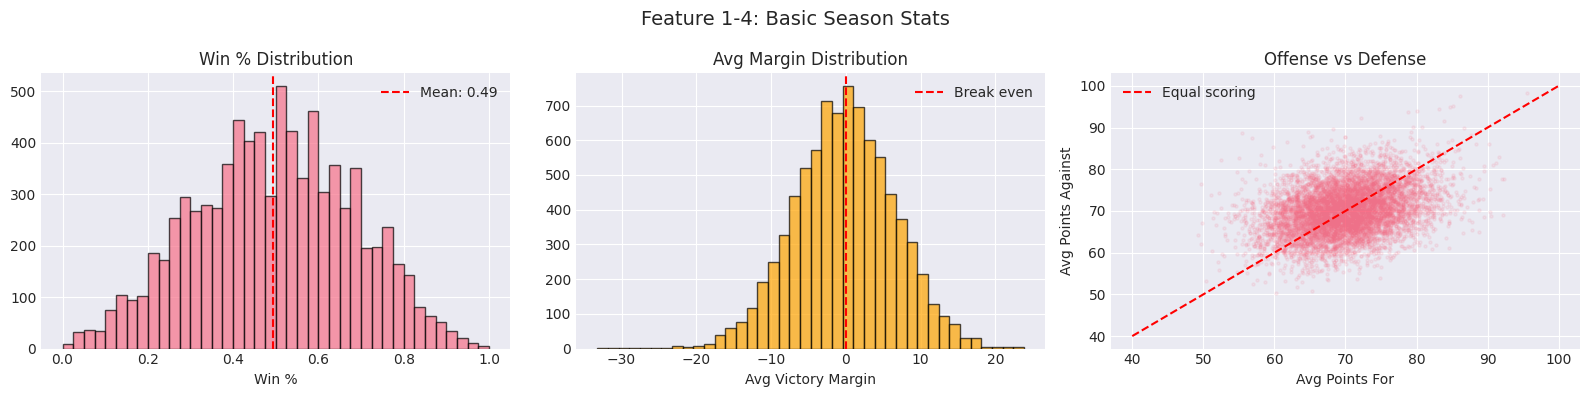

Points BELOW the red line = good teams (score more than they allow)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(basic_stats['WinPct'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Win %')
axes[0].set_title('Win % Distribution')
axes[0].axvline(basic_stats['WinPct'].mean(), color='red', linestyle='--', label=f"Mean: {basic_stats['WinPct'].mean():.2f}")
axes[0].legend()

axes[1].hist(basic_stats['AvgMargin'], bins=40, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Avg Victory Margin')
axes[1].set_title('Avg Margin Distribution')
axes[1].axvline(0, color='red', linestyle='--', label='Break even')
axes[1].legend()

axes[2].scatter(basic_stats['AvgPointsFor'], basic_stats['AvgPointsAgainst'], alpha=0.1, s=5)
axes[2].plot([40, 100], [40, 100], 'r--', label='Equal scoring')
axes[2].set_xlabel('Avg Points For')
axes[2].set_ylabel('Avg Points Against')
axes[2].set_title('Offense vs Defense')
axes[2].legend()

plt.suptitle('Feature 1-4: Basic Season Stats', fontsize=14)
plt.tight_layout()
plt.show()

print("Points BELOW the red line = good teams (score more than they allow)")

---
## 2. Four Factors (Dean Oliver)

From detailed box scores — the 4 stats that explain ~90% of winning:

| Factor | Formula | Good Value |
|--------|---------|------------|
| `eFG_Off` | (FGM + 0.5 x FGM3) / FGA | Higher = better |
| `TORate_Off` | TO / (FGA + 0.44 x FTA + TO) | **Lower** = better |
| `ORBRate_Off` | OR / (OR + Opp_DR) | Higher = better |
| `FTRate_Off` | FTM / FGA | Higher = better |

In [17]:
detailed = load_regular_season_results('M', detailed=True)
detailed = detailed[detailed['Season'] >= YEAR_START]
print(f"Detailed games: {len(detailed):,} ({detailed['Season'].min()}-{detailed['Season'].max()})")

four_factors_games = calculate_four_factors(detailed)
four_factors = aggregate_four_factors(four_factors_games)
print(f"Four Factors: {four_factors.shape[0]:,} team-seasons")
print(f"NaN count: {four_factors.isnull().sum().sum()}")
four_factors.head()

Detailed games: 122,775 (2003-2026)
Four Factors: 8,346 team-seasons
NaN count: 0


,Season,TeamID,eFG_Off,TORate_Off,ORBRate_Off,FTRate_Off
0,2003,1102,0.597877,0.191736,0.168729,0.299491
1,2003,1103,0.538566,0.159640,0.306256,0.345079
2,2003,1104,0.467529,0.169183,0.372403,0.259957
3,2003,1105,0.467589,0.204540,0.350317,0.274268
4,2003,1106,0.484095,0.214153,0.351445,0.202964


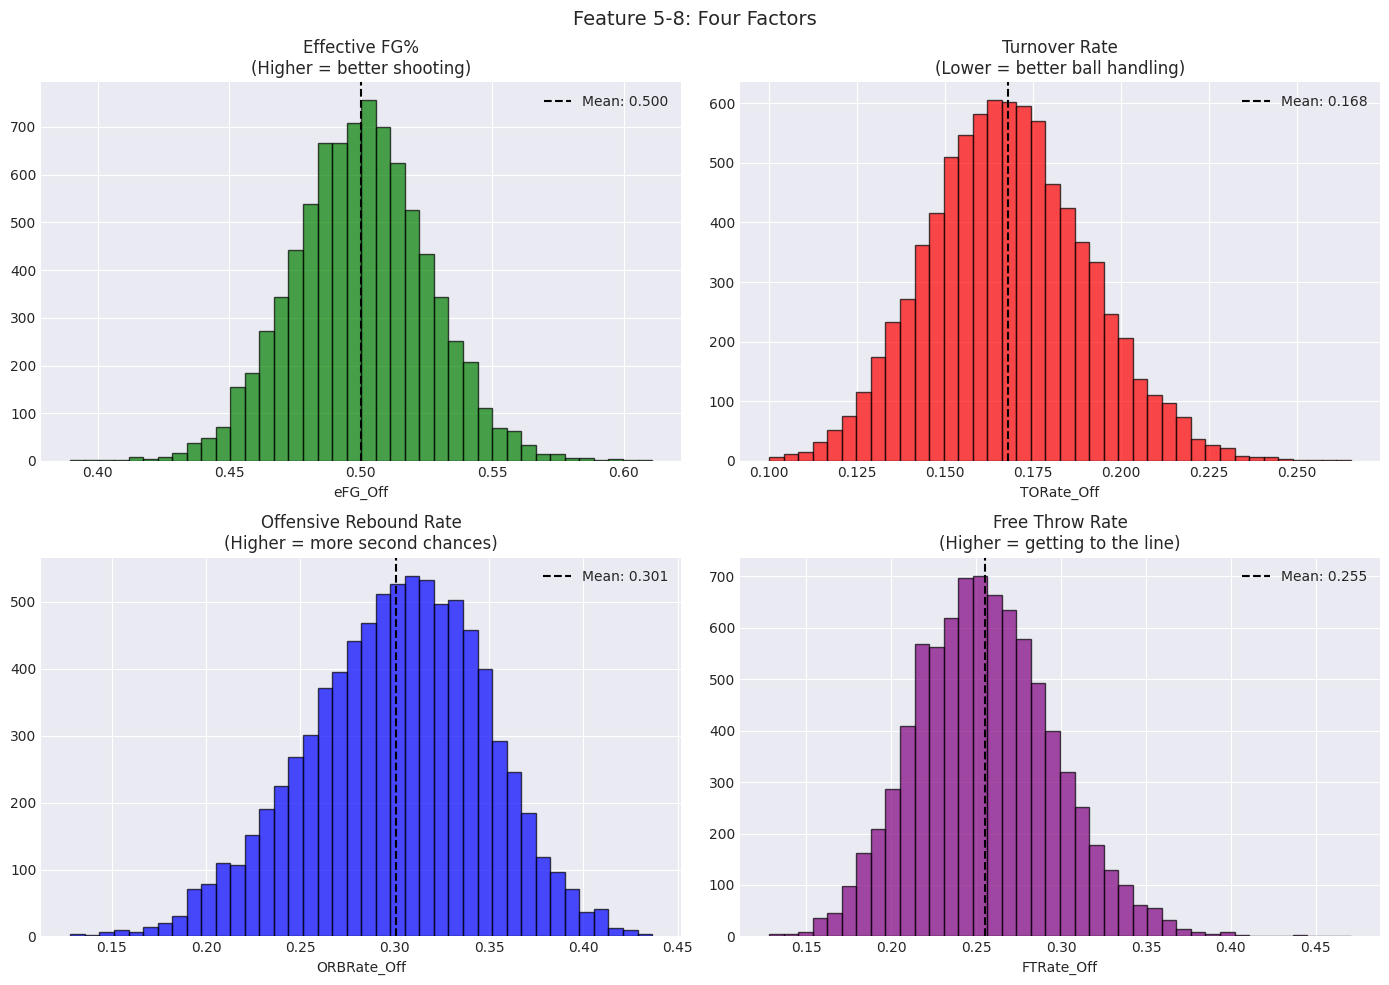

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

factor_info = [
    ('eFG_Off', 'Effective FG%', 'Higher = better shooting', 'green'),
    ('TORate_Off', 'Turnover Rate', 'Lower = better ball handling', 'red'),
    ('ORBRate_Off', 'Offensive Rebound Rate', 'Higher = more second chances', 'blue'),
    ('FTRate_Off', 'Free Throw Rate', 'Higher = getting to the line', 'purple')
]

for ax, (col, title, desc, color) in zip(axes.flatten(), factor_info):
    ax.hist(four_factors[col], bins=40, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(four_factors[col].mean(), color='black', linestyle='--',
               label=f"Mean: {four_factors[col].mean():.3f}")
    ax.set_xlabel(col)
    ax.set_title(f'{title}\n({desc})')
    ax.legend()

plt.suptitle('Feature 5-8: Four Factors', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Elo Ratings

Every team starts at **1500**. Win -> goes up. Lose -> goes down.

**Key:** Beat a strong team = big boost. Lose to weak team = big drop.

Formula: `Expected = 1 / (1 + 10^((Opp_Elo - Your_Elo) / 200))`

In [19]:
print("Calculating Elo ratings (this may take a minute)...")
elo_history = calculate_elo_ratings(regular)

# Get end-of-regular-season Elo for each team
elo_final = elo_history.sort_values('DayNum').groupby(['Season', 'TeamID']).tail(1)
elo_final = elo_final[['Season', 'TeamID', 'Elo']].rename(columns={'Elo': 'Elo_RegSeason'})
print(f"Elo ratings: {elo_final.shape[0]:,} team-seasons")
elo_final.head()

Calculating Elo ratings (this may take a minute)...
Elo ratings: 8,346 team-seasons


,Season,TeamID,Elo_RegSeason
187164,2021,1224,1470.800549
187341,2021,1152,1390.629452
189213,2021,1263,1446.341641
53057,2008,1223,1403.561514
244928,2026,1414,1571.983207


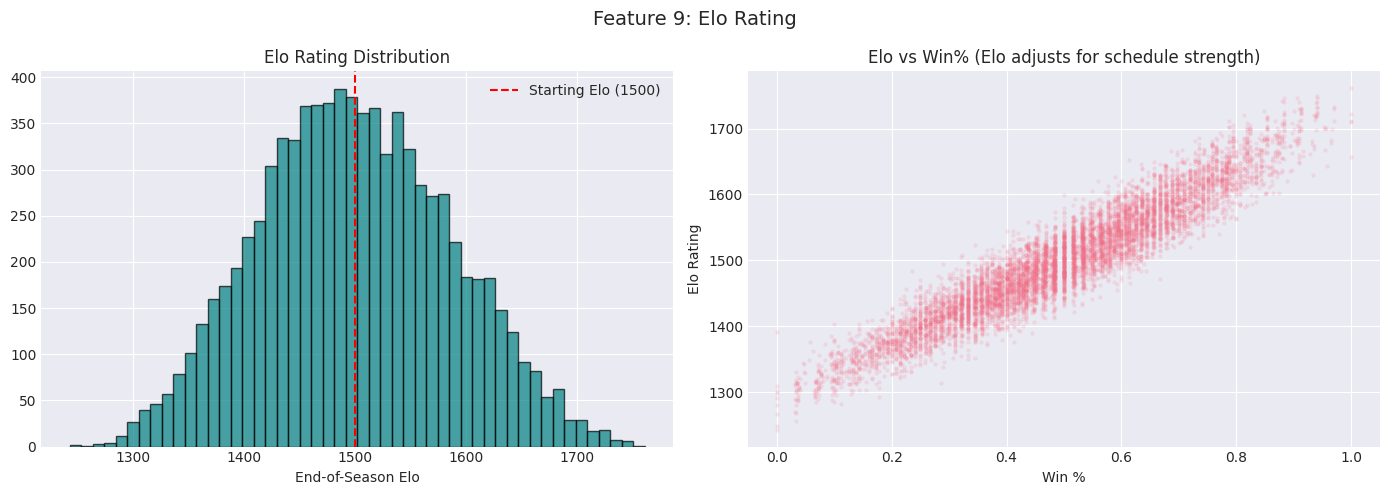

Elo and Win% are correlated but NOT identical.
Teams with same Win% can have different Elo = different schedule strength.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(elo_final['Elo_RegSeason'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(1500, color='red', linestyle='--', label='Starting Elo (1500)')
axes[0].set_xlabel('End-of-Season Elo')
axes[0].set_title('Elo Rating Distribution')
axes[0].legend()

merged_elo = elo_final.merge(basic_stats[['Season', 'TeamID', 'WinPct']], on=['Season', 'TeamID'])
axes[1].scatter(merged_elo['WinPct'], merged_elo['Elo_RegSeason'], alpha=0.1, s=5)
axes[1].set_xlabel('Win %')
axes[1].set_ylabel('Elo Rating')
axes[1].set_title('Elo vs Win% (Elo adjusts for schedule strength)')

plt.suptitle('Feature 9: Elo Rating', fontsize=14)
plt.tight_layout()
plt.show()

print("Elo and Win% are correlated but NOT identical.")
print("Teams with same Win% can have different Elo = different schedule strength.")

---
## 4. POM & SAG Rankings

| System | What It Measures |
|--------|------------------|
| **POM** (Pomeroy) | Efficiency: points per 100 possessions |
| **SAG** (Sagarin) | Point-spread: expected margin vs average team |
| **Composite** | Average of all 196 systems |

In [21]:
print("Loading Massey Ordinals (127MB, may take a moment)...")
massey = load_massey_ordinals()
massey = massey[massey['Season'] >= YEAR_START]

# Get pre-tournament rankings (DayNum 128-133)
pre_tourney = massey[massey['RankingDayNum'] >= 128]
pre_tourney = pre_tourney.sort_values('RankingDayNum').groupby(
    ['Season', 'SystemName', 'TeamID']
).tail(1)

print(f"Pre-tournament rankings: {len(pre_tourney):,} rows")

Loading Massey Ordinals (127MB, may take a moment)...
Pre-tournament rankings: 424,183 rows


In [22]:
# Extract individual systems
pom = pre_tourney[pre_tourney['SystemName'] == 'POM'][['Season', 'TeamID', 'OrdinalRank']]
pom = pom.rename(columns={'OrdinalRank': 'POM_Rank'})
print(f"POM rankings: {len(pom)} team-seasons")

sag = pre_tourney[pre_tourney['SystemName'] == 'SAG'][['Season', 'TeamID', 'OrdinalRank']]
sag = sag.rename(columns={'OrdinalRank': 'SAG_Rank'})
print(f"SAG rankings: {len(sag)} team-seasons")

# Composite rank
composite = pre_tourney.groupby(['Season', 'TeamID']).agg(
    Composite_Rank=('OrdinalRank', 'mean')
).reset_index()
print(f"Composite rankings: {len(composite)} team-seasons")

POM rankings: 7977 team-seasons
SAG rankings: 7254 team-seasons
Composite rankings: 7980 team-seasons


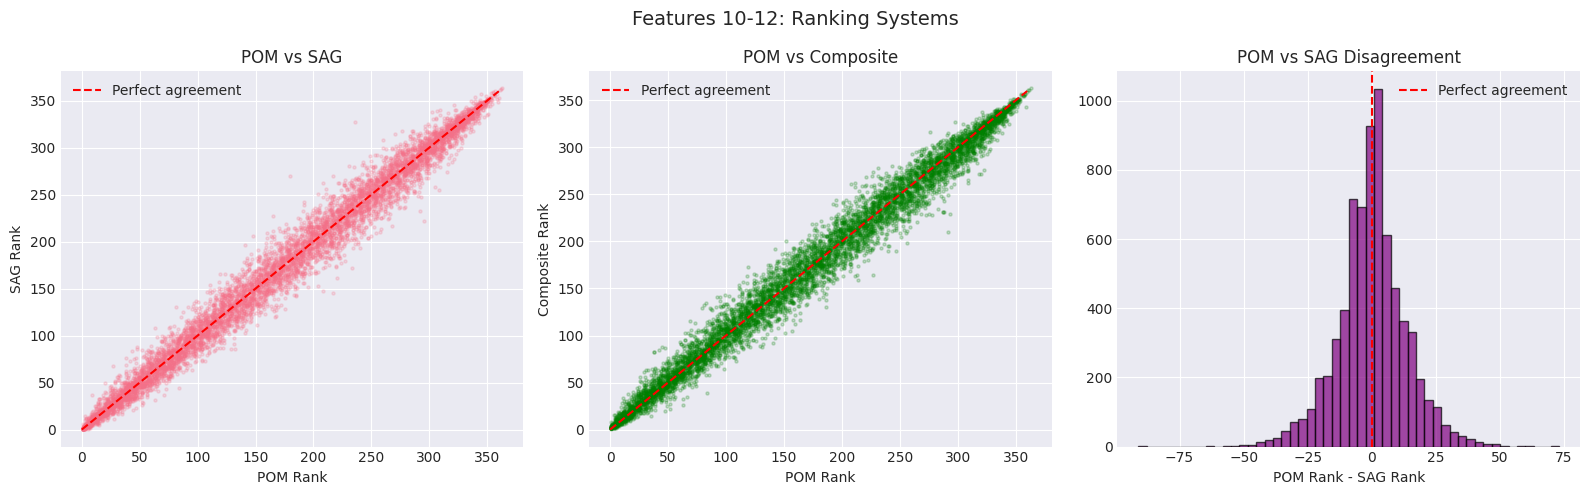

POM-SAG correlation: 0.991
They mostly agree, but disagreements give the model extra signal.


In [23]:
# Visualize: POM vs SAG
pom_sag = pom.merge(sag, on=['Season', 'TeamID']).merge(composite, on=['Season', 'TeamID'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(pom_sag['POM_Rank'], pom_sag['SAG_Rank'], alpha=0.2, s=5)
axes[0].plot([0, 360], [0, 360], 'r--', label='Perfect agreement')
axes[0].set_xlabel('POM Rank')
axes[0].set_ylabel('SAG Rank')
axes[0].set_title('POM vs SAG')
axes[0].legend()

axes[1].scatter(pom_sag['POM_Rank'], pom_sag['Composite_Rank'], alpha=0.2, s=5, color='green')
axes[1].plot([0, 360], [0, 360], 'r--', label='Perfect agreement')
axes[1].set_xlabel('POM Rank')
axes[1].set_ylabel('Composite Rank')
axes[1].set_title('POM vs Composite')
axes[1].legend()

pom_sag['POM_SAG_Diff'] = pom_sag['POM_Rank'] - pom_sag['SAG_Rank']
axes[2].hist(pom_sag['POM_SAG_Diff'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[2].axvline(0, color='red', linestyle='--', label='Perfect agreement')
axes[2].set_xlabel('POM Rank - SAG Rank')
axes[2].set_title('POM vs SAG Disagreement')
axes[2].legend()

plt.suptitle('Features 10-12: Ranking Systems', fontsize=14)
plt.tight_layout()
plt.show()

corr = pom_sag['POM_Rank'].corr(pom_sag['SAG_Rank'])
print(f"POM-SAG correlation: {corr:.3f}")
print("They mostly agree, but disagreements give the model extra signal.")

---
## 4b. Conference Strength

Rank conferences by average Elo of their teams. **1 = strongest conference** (e.g., SEC, Big 12).

Conference assignments: 8,346 rows
Conference strength: 8,346 team-seasons

2025 Top 10 Conferences:
  # 1  sec
  # 2  big_ten
  # 3  big_twelve
  # 4  big_east
  # 5  acc
  # 6  a_ten
  # 7  mwc
  # 8  mvc
  # 9  cusa
  #10  wcc


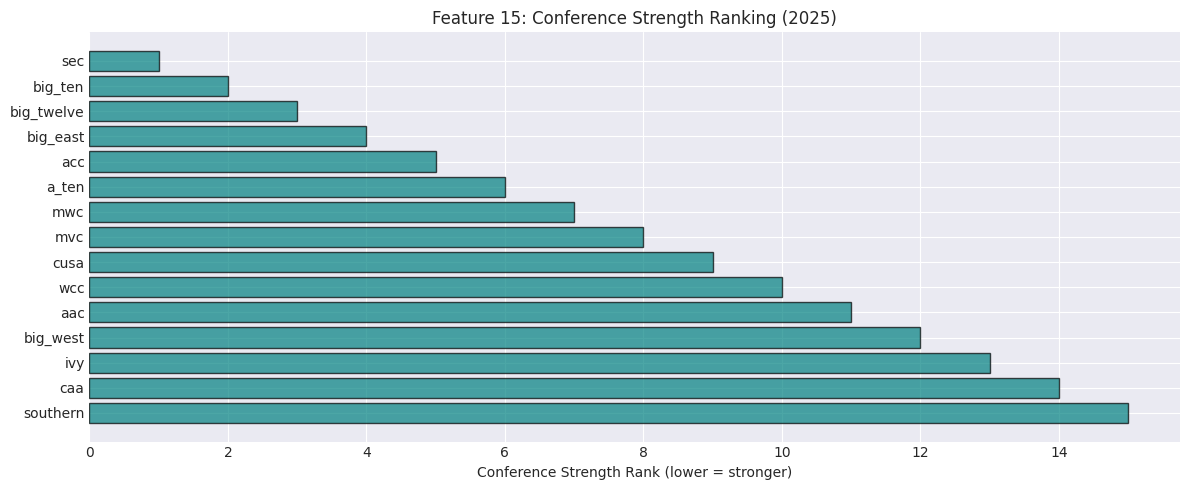

In [24]:
# Conference strength: rank conferences by avg Elo of their teams
conferences = load_team_conferences('M')
conferences = conferences[conferences['Season'] >= YEAR_START]
print(f"Conference assignments: {len(conferences):,} rows")

conf_strength = calculate_conference_strength(conferences, elo_final)
print(f"Conference strength: {len(conf_strength):,} team-seasons")

# Show top 10 conferences for 2025
conf_2025 = conf_strength[conf_strength['Season'] == 2025].drop_duplicates('ConfAbbrev').sort_values('ConfStrength_Rank')
print(f"\n2025 Top 10 Conferences:")
for _, row in conf_2025.head(10).iterrows():
    print(f"  #{int(row['ConfStrength_Rank']):2d}  {row['ConfAbbrev']}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(conf_2025.head(15)['ConfAbbrev'][::-1], 
        conf_2025.head(15)['ConfStrength_Rank'][::-1], 
        edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('Conference Strength Rank (lower = stronger)')
ax.set_title('Feature 15: Conference Strength Ranking (2025)')
plt.tight_layout()
plt.show()

---
## 4c. Last 15 Games (Momentum)

Season averages hide late-season trends. A team that starts 5-10 but finishes 15-2 is **peaking** heading into March.

Last 15 stats: 8,346 team-seasons

Season WinPct vs Last15 WinPct correlation: 0.863
Season AvgMargin vs Last15 AvgMargin correlation: 0.842


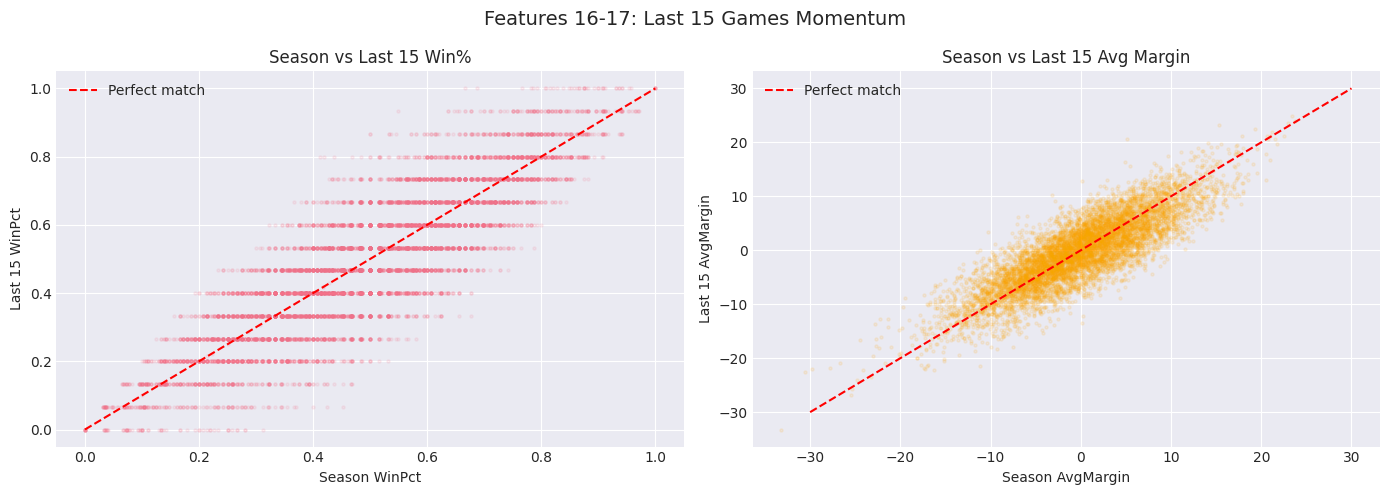

Points far from the red line = teams whose form changed late in the season.
These are the teams where Last15 adds value over season averages.


In [25]:
# Last 15 games: WinPct and AvgMargin over final 15 regular season games
last15 = calculate_last_n_games(regular, n=15)
print(f"Last 15 stats: {len(last15):,} team-seasons")

# Compare season avg vs last 15
comparison = basic_stats.merge(last15, on=['Season', 'TeamID'])
print(f"\nSeason WinPct vs Last15 WinPct correlation: {comparison['WinPct'].corr(comparison['Last15WinPct']):.3f}")
print(f"Season AvgMargin vs Last15 AvgMargin correlation: {comparison['AvgMargin'].corr(comparison['Last15AvgMargin']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(comparison['WinPct'], comparison['Last15WinPct'], alpha=0.1, s=5)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect match')
axes[0].set_xlabel('Season WinPct')
axes[0].set_ylabel('Last 15 WinPct')
axes[0].set_title('Season vs Last 15 Win%')
axes[0].legend()

axes[1].scatter(comparison['AvgMargin'], comparison['Last15AvgMargin'], alpha=0.1, s=5, color='orange')
axes[1].plot([-30, 30], [-30, 30], 'r--', label='Perfect match')
axes[1].set_xlabel('Season AvgMargin')
axes[1].set_ylabel('Last 15 AvgMargin')
axes[1].set_title('Season vs Last 15 Avg Margin')
axes[1].legend()

plt.suptitle('Features 16-17: Last 15 Games Momentum', fontsize=14)
plt.tight_layout()
plt.show()

print("Points far from the red line = teams whose form changed late in the season.")
print("These are the teams where Last15 adds value over season averages.")

---
## 4d. Conference Tournament Champion

Teams that won their conference tournament enter March Madness with **momentum and confidence**.

In [26]:
# Conference tournament champions
conf_tourney = load_conference_tourney_games('M')
conf_tourney = conf_tourney[conf_tourney['Season'] >= YEAR_START]
print(f"Conference tournament games: {len(conf_tourney):,}")
print(f"Seasons: {conf_tourney['Season'].min()} to {conf_tourney['Season'].max()}")

conf_champs = calculate_conf_tourney_champ(conf_tourney)
print(f"\nConference champions identified: {len(conf_champs):,} team-seasons")
print(f"Champions per season: ~{len(conf_champs) // conf_tourney['Season'].nunique()} conferences")

# Show 2025 champions
champs_2025 = conf_champs[conf_champs['Season'] == 2025].copy()
champs_2025['TeamName'] = champs_2025['TeamID'].map(team_lookup)
print(f"\n2025 Conference Tournament Champions ({len(champs_2025)}):")
for _, row in champs_2025.iterrows():
    print(f"  {row['TeamName']}")

Conference tournament games: 6,298
Seasons: 2003 to 2025

Conference champions identified: 709 team-seasons
Champions per season: ~30 conferences

2025 Conference Tournament Champions (31):
  SIUE
  NE Omaha
  Drake
  High Point
  Lipscomb
  Troy
  Wofford
  St Francis PA
  UNC Wilmington
  Robert Morris
  Gonzaga
  American Univ
  Montana
  McNeese St
  Mt St Mary's
  Norfolk St
  Alabama St
  Bryant
  UC San Diego
  Colorado St
  Duke
  Grand Canyon
  Houston
  Liberty
  St John's
  Akron
  Florida
  Memphis
  Michigan
  VCU
  Yale


---
## 5. Tournament Seeds

In [27]:
seeds = load_seeds('M')
seeds = seeds[seeds['Season'] >= YEAR_START]
seed_features = calculate_seed_features(seeds)

print(f"Seed features: {seed_features.shape[0]} team-seasons")
seed_features.head()

Seed features: 1472 team-seasons


,Season,TeamID,Seed,Region,SeedNum,IsPlayIn
1154,2003,1328,W01,W,1,False
1155,2003,1448,W02,W,2,False
1156,2003,1393,W03,W,3,False
1157,2003,1257,W04,W,4,False
1158,2003,1280,W05,W,5,False


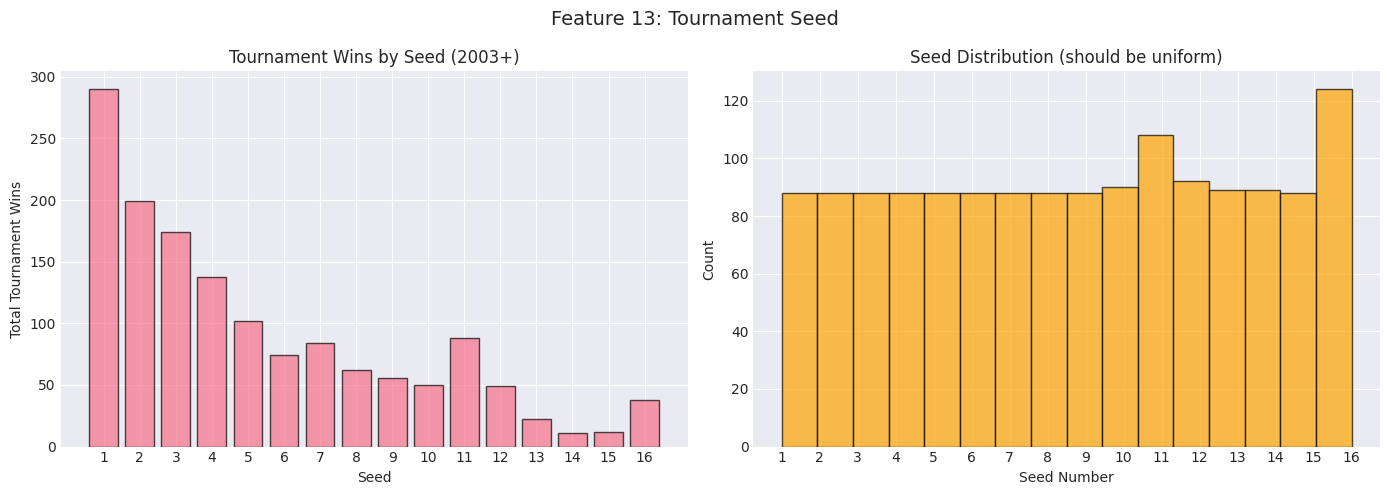

Seed 1 wins the most games. Seed is the single strongest predictor.


In [28]:
# Seed vs tournament wins
tourney = load_tourney_results('M')
tourney = tourney[tourney['Season'] >= YEAR_START]

tourney_seeds = tourney.merge(seed_features, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID'])
wins_by_seed = tourney_seeds.groupby('SeedNum').size().reset_index(name='TotalWins')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(wins_by_seed['SeedNum'], wins_by_seed['TotalWins'], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Seed')
axes[0].set_ylabel('Total Tournament Wins')
axes[0].set_title('Tournament Wins by Seed (2003+)')
axes[0].set_xticks(range(1, 17))

axes[1].hist(seed_features['SeedNum'], bins=16, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Seed Number')
axes[1].set_ylabel('Count')
axes[1].set_title('Seed Distribution (should be uniform)')
axes[1].set_xticks(range(1, 17))

plt.suptitle('Feature 13: Tournament Seed', fontsize=14)
plt.tight_layout()
plt.show()

print("Seed 1 wins the most games. Seed is the single strongest predictor.")

---
## 6. Merge All Features Into One Table

In [29]:
team_features = basic_stats.copy()
team_features = team_features.merge(four_factors, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(elo_final, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(pom, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(sag, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(composite, on=['Season', 'TeamID'], how='left')
team_features = team_features.merge(
    seed_features[['Season', 'TeamID', 'SeedNum']],
    on=['Season', 'TeamID'], how='left'
)

# IsSeeded: 1 if team made the tournament, 0 if not
team_features['IsSeeded'] = team_features['SeedNum'].notna().astype(int)

# Fill unseeded teams with 100 (far worse than worst seed of 16)
team_features['SeedNum'] = team_features['SeedNum'].fillna(100)

# NEW: Conference strength rank
team_features = team_features.merge(
    conf_strength[['Season', 'TeamID', 'ConfStrength_Rank']],
    on=['Season', 'TeamID'], how='left'
)

# NEW: Last 15 games momentum
team_features = team_features.merge(last15, on=['Season', 'TeamID'], how='left')

# NEW: Conference tournament champion (default 0 for non-champions)
team_features = team_features.merge(conf_champs, on=['Season', 'TeamID'], how='left')
team_features['ConfTourneyChamp'] = team_features['ConfTourneyChamp'].fillna(0).astype(int)

print(f"Final team features: {team_features.shape}")
print(f"Seasons: {team_features['Season'].min()} to {team_features['Season'].max()}")
print(f"\nData completeness:")
for col in team_features.columns:
    pct = 100 * team_features[col].notna().sum() / len(team_features)
    print(f"  {col}: {pct:.0f}%")

Final team features: (8346, 23)
Seasons: 2003 to 2026

Data completeness:
  Season: 100%
  TeamID: 100%
  Games: 100%
  Wins: 100%
  Losses: 100%
  WinPct: 100%
  AvgPointsFor: 100%
  AvgPointsAgainst: 100%
  AvgMargin: 100%
  eFG_Off: 100%
  TORate_Off: 100%
  ORBRate_Off: 100%
  FTRate_Off: 100%
  Elo_RegSeason: 100%
  POM_Rank: 96%
  SAG_Rank: 87%
  Composite_Rank: 96%
  SeedNum: 100%
  IsSeeded: 100%
  ConfStrength_Rank: 100%
  Last15WinPct: 100%
  Last15AvgMargin: 100%
  ConfTourneyChamp: 100%


In [30]:
# Sanity check: 2025 top teams with all features
top_2025 = team_features[team_features['Season'] == 2025].sort_values('Composite_Rank').head(15)
top_2025['TeamName'] = top_2025['TeamID'].map(team_lookup)
display(top_2025[['TeamName', 'WinPct', 'AvgMargin', 'Elo_RegSeason', 'Composite_Rank',
                  'SeedNum', 'ConfStrength_Rank', 'Last15WinPct', 'Last15AvgMargin', 'ConfTourneyChamp']])

,TeamName,WinPct,AvgMargin,Elo_RegSeason,Composite_Rank,SeedNum,ConfStrength_Rank,Last15WinPct,Last15AvgMargin,ConfTourneyChamp
7691,Duke,0.911765,20.794118,1730.607631,2.214286,1.0,5,0.933333,20.533333,1
7634,Auburn,0.848485,14.242424,1684.499458,2.321429,1.0,1,0.733333,7.800000,0
7706,Florida,0.882353,16.176471,1740.750861,2.642857,1.0,1,0.866667,12.200000,1
7730,Houston,0.882353,15.735294,1746.785826,3.339286,1.0,3,0.933333,9.000000,1
7620,Alabama,0.757576,9.696970,1676.904068,5.553571,2.0,1,0.666667,7.066667,0
7900,Tennessee,0.794118,11.705882,1686.144325,5.803571,2.0,1,0.666667,4.066667,0
7785,Michigan St,0.818182,10.909091,1693.718475,8.482143,2.0,2,0.733333,7.200000,0
7888,St John's,0.882353,12.823529,1713.004805,9.142857,2.0,4,0.933333,10.666667,1
7906,Texas Tech,0.757576,13.333333,1640.298768,12.339286,3.0,3,0.733333,8.600000,0
7776,Maryland,0.757576,14.666667,1656.305817,13.125000,4.0,2,0.800000,8.800000,0


---
## 7. Save Team Features

In [31]:
team_features.to_csv(PROCESSED_DIR / 'team_features.csv', index=False)
print(f"Saved: processed/team_features.csv ({team_features.shape})")

print(f"\nFeatures saved:")
feature_list = [
    ('WinPct', 'Win percentage'),
    ('AvgPointsFor', 'Average points scored'),
    ('AvgPointsAgainst', 'Average points allowed'),
    ('AvgMargin', 'Average victory margin'),
    ('eFG_Off', 'Effective FG% (Four Factors)'),
    ('TORate_Off', 'Turnover rate (Four Factors)'),
    ('ORBRate_Off', 'Offensive rebound rate (Four Factors)'),
    ('FTRate_Off', 'Free throw rate (Four Factors)'),
    ('Elo_RegSeason', 'End-of-season Elo rating'),
    ('POM_Rank', 'Pomeroy ranking'),
    ('SAG_Rank', 'Sagarin ranking'),
    ('Composite_Rank', 'Average of 196 ranking systems'),
    ('SeedNum', 'Tournament seed (1-16, 100=unseeded)'),
    ('IsSeeded', 'Binary: 1=made tournament, 0=did not'),
    ('ConfStrength_Rank', 'Conference strength ranking (1=best)'),
    ('Last15WinPct', 'Win % over last 15 games'),
    ('Last15AvgMargin', 'Avg margin over last 15 games'),
    ('ConfTourneyChamp', 'Binary: 1=won conference tournament'),
]
for i, (col, desc) in enumerate(feature_list, 1):
    print(f"  {i:2d}. {col:<20s} -> {desc}")

print(f"\nNext: Run 04b_matchup_building.ipynb")

Saved: processed/team_features.csv ((8346, 23))

Features saved:
   1. WinPct               -> Win percentage
   2. AvgPointsFor         -> Average points scored
   3. AvgPointsAgainst     -> Average points allowed
   4. AvgMargin            -> Average victory margin
   5. eFG_Off              -> Effective FG% (Four Factors)
   6. TORate_Off           -> Turnover rate (Four Factors)
   7. ORBRate_Off          -> Offensive rebound rate (Four Factors)
   8. FTRate_Off           -> Free throw rate (Four Factors)
   9. Elo_RegSeason        -> End-of-season Elo rating
  10. POM_Rank             -> Pomeroy ranking
  11. SAG_Rank             -> Sagarin ranking
  12. Composite_Rank       -> Average of 196 ranking systems
  13. SeedNum              -> Tournament seed (1-16, 100=unseeded)
  14. IsSeeded             -> Binary: 1=made tournament, 0=did not
  15. ConfStrength_Rank    -> Conference strength ranking (1=best)
  16. Last15WinPct         -> Win % over last 15 games
  17. Last15AvgMargin